# Minimum, Maximum, Mixture

In the last chapter, we computed distributions of sums. Here, we'll compute distributions of minimums and maximums, and use them to solve both Forward and Inverse Problems. 

Then, we'll look at distributions that are mixtures of other distributions, which can be very helpful. 

First, let's learn a powerful tool for working with distributions, the cumulative distribution function. 

## Cumulative Distribution Functions

CDF can serve as an alternative to Pmf. For an example, let's use the posterior from the Euro problem:

In [1]:
import numpy as np
from empiricaldist import Pmf

hypos = np.linspace(0, 1, 101)
pmf = Pmf(1, hypos)
data = 140, 250

Here's the update:

In [2]:
from scipy.stats import binom

def update_binomial(pmf, data):
    k, n = data
    xs = pmf.qs
    likelihood = binom.pmf(k, n, xs)
    pmf *= likelihood
    pmf.normalize()

update_binomial(pmf, data)

cumulative = pmf.cumsum()

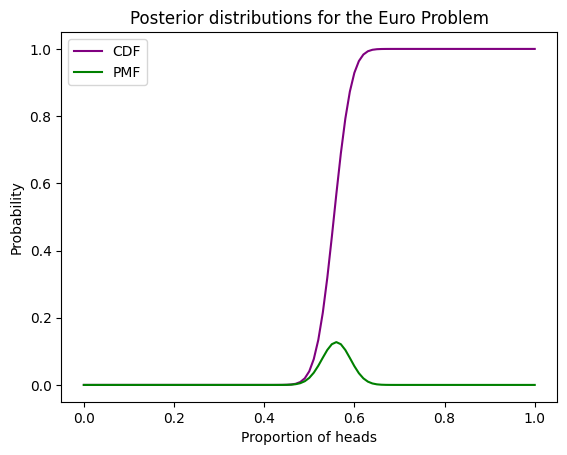

In [8]:
import matplotlib.pyplot as plt

cumulative.plot(label='CDF', color = 'purple')
pmf.plot(label='PMF', color = 'green')
plt.xlabel('Proportion of heads')
plt.ylabel('Probability')
plt.title('Posterior distributions for the Euro Problem')  
plt.legend()
plt.show()

The range of CDF is always from 0 to 1. This is in contrast to the PMF which allows for any probability to be the maximum. 

In [9]:
cumulative[.61]

np.float64(0.9638303193984252)

Using the cumsum, we can see that the total probability of all quantities less that or equal to .61 is 96%. 

We can also go the other way to look up a probability and get a corresponding quantile. 

In [10]:
from scipy.interpolate import interp1d

ps = cumulative.values
qs = cumulative.index

interp = interp1d(ps, qs)
interp(.96)

array(0.60890171)

You can also use a pmf to made a cdf:

In [11]:
cdf = pmf.make_cdf()

cdf[.61]

np.float64(0.9638303193984252)

To look up a quantity, call a cdf as a function using parentheses:

In [12]:
cdf(.615)

array(0.96383032)

Going the other way, you can look up a quantile to look up cumulative probability and get the corresponding quantity:

In [13]:
cdf.quantile(.96)

array(0.61)

Cdf also provides a credible_interval, which computes a credible interval that contains a given probability:

In [14]:
print(cdf.credible_interval(.9))

print(cdf.credible_interval(.95))

print(cdf.credible_interval(.99))

[0.51 0.61]
[0.5  0.62]
[0.48 0.64]


You can also go from cdf to pmf:

In [15]:
pmf = cdf.make_pmf()

## Best Three of Four

In Dungeons and Dragons, each character has six attributes: strength, intelligence, wisdon, dexterity, constitutions, and charisma. 

To generate a new character, players roll four 6-sided dice and add up the highest (best) three results. 

Let's simulate this:

In [16]:
from utils import make_die

die = make_die(6)
dice = [die] * 3

In [17]:
from utils import add_dist_seq

pmf_3d6 = add_dist_seq(dice)

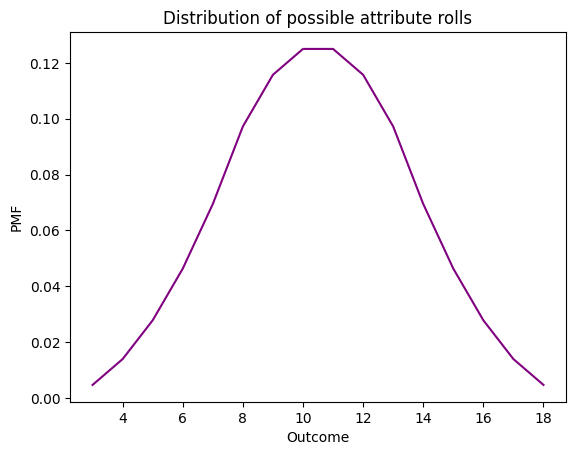

In [19]:
pmf_3d6.plot(color = 'purple')
plt.xlabel('Outcome')
plt.ylabel('PMF')
plt.title('Distribution of possible attribute rolls')  
plt.show()

Let's simulate 10,000 rolls

In [22]:
n = 10000 #10,000 rolls
a = np.random.randint(1, 7, size = (n, 4)) # outcomes 1 to 6, 4 columns (rolls)

a.sort(axis = 1) # find the best three outcomes and sort them
t = a[:,1:].sum(axis = 1) # select the last three columns
pmf_best3 = pmf.from_seq(t) # set 't' as an array and compute a pmf

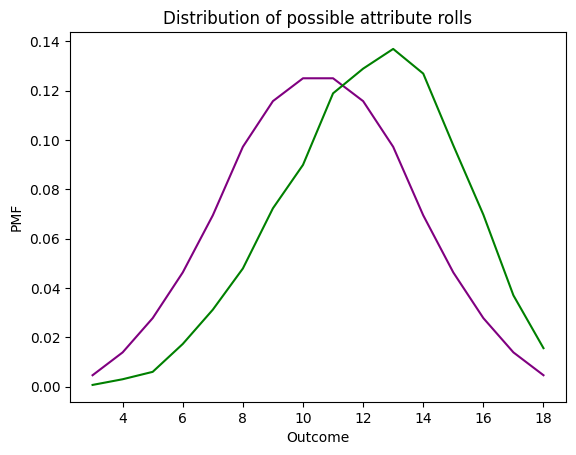

In [23]:
pmf_3d6.plot(label = 'sum of 3 dice', color = 'purple')
pmf_best3.plot(label = 'best 3 of 4', color = 'green')
plt.xlabel('Outcome')
plt.ylabel('PMF')
plt.title('Distribution of possible attribute rolls')  
plt.show()